# 🎮 Video Game Sales Prediction using Machine Learning

## Predicción de Ventas de Videojuegos mediante Machine Learning

### Business Understanding / Comprensión del Negocio

**English**

The objective of this project is to predict global video game sales using information available before the game is released. Different regression models are compared in order to identify the most suitable approach for this problem.

**Español**

El objetivo de este proyecto es predecir las ventas globales de videojuegos utilizando únicamente información disponible antes del lanzamiento del juego. Se comparan distintos modelos de regresión para identificar el enfoque con mejor desempeño.


# 1. Import Libraries / Importación de Librerías

The following libraries are required for data manipulation, visualization and Machine Learning.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Dataset / Carga del Dataset

The dataset is loaded into a Pandas DataFrame and inspected before preprocessing begins.

In [14]:
games_df = pd.read_csv("Data_sets\\Videojuegos\\vgchartz-2024.csv")
games_df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


# 3. Data Understanding / Comprensión de los Datos

The structure of the dataset is inspected, including dimensions, data types, duplicated rows and missing values.

In [15]:
print(games_df.shape)
games_df.info()
print("Duplicated rows:", games_df.duplicated().sum())

(64016, 14)
<class 'pandas.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  str    
 1   title         64016 non-null  str    
 2   console       64016 non-null  str    
 3   genre         64016 non-null  str    
 4   publisher     64016 non-null  str    
 5   developer     63999 non-null  str    
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  str    
 13  last_update   17879 non-null  str    
dtypes: float64(6), str(8)
memory usage: 13.6 MB
Duplicated rows: 0


# 4. Data Cleaning / Limpieza de Datos

**Removed features**

- Data leakage (`na_sales`, `jp_sales`, `pal_sales`, `other_sales`)
- Irrelevant information (`img`, `title`)
- Information unavailable before release (`critic_score`, `last_update`)

Rows without the target variable are removed because supervised learning requires known labels.


In [16]:
games_df = games_df.dropna(subset=["total_sales"])

games_df = games_df.drop(columns=[
    "img","title","critic_score",
    "na_sales","jp_sales","pal_sales","other_sales",
    "last_update"
])

games_df = games_df.dropna(subset=["developer","release_date"])

games_df.info()

<class 'pandas.DataFrame'>
Index: 18829 entries, 0 to 18921
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   console       18829 non-null  str    
 1   genre         18829 non-null  str    
 2   publisher     18829 non-null  str    
 3   developer     18829 non-null  str    
 4   total_sales   18829 non-null  float64
 5   release_date  18829 non-null  str    
dtypes: float64(1), str(5)
memory usage: 1.8 MB


# 5. Feature Engineering / Ingeniería de Variables

The release date is converted into datetime format and transformed into two numerical features:

- release_year
- release_month


In [17]:
games_df["release_date"] = pd.to_datetime(games_df["release_date"])

games_df["release_year"] = games_df["release_date"].dt.year
games_df["release_month"] = games_df["release_date"].dt.month

games_df = games_df.drop(columns=["release_date"])

# 6. Categorical Encoding / Codificación de Variables

Two encoding strategies are used.

| Feature | Encoding |
|---------|----------|
| publisher | Frequency Encoding |
| developer | Frequency Encoding |
| console | One-Hot Encoding |
| genre | One-Hot Encoding |


In [18]:
publisher_frequency = games_df["publisher"].value_counts(normalize=True)
games_df["publisher"] = games_df["publisher"].map(publisher_frequency)

developer_frequency = games_df["developer"].value_counts(normalize=True)
games_df["developer"] = games_df["developer"].map(developer_frequency)

games_df = pd.get_dummies(
    games_df,
    columns=["console","genre"],
    dtype=int
)

games_df.shape

(18829, 64)

# 7. Exploratory Data Analysis (EDA)

The target variable is analyzed to identify skewness and justify the models evaluated later.


count    18829.000000
mean         0.350475
std          0.809095
min          0.000000
25%          0.030000
50%          0.120000
75%          0.350000
max         20.320000
Name: total_sales, dtype: float64


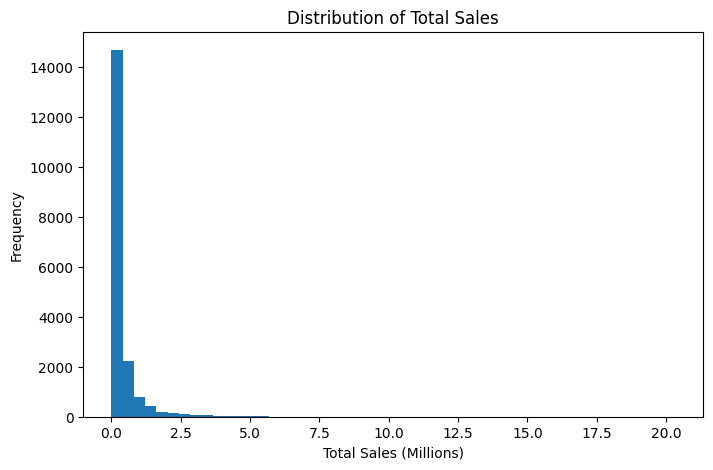

In [19]:
print(games_df["total_sales"].describe())

plt.figure(figsize=(8,5))
plt.hist(games_df["total_sales"], bins=50)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales (Millions)")
plt.ylabel("Frequency")
plt.show()

# 8. Train/Test Split

The dataset is divided into training (80%) and testing (20%) subsets.


In [20]:
X = games_df.drop(columns=["total_sales"])
y = games_df["total_sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 9. Model 1 — Linear Regression

In [21]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)

y_pred = linear_model.predict(X_test)

print("Linear Regression")
print("MAE :",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R²  :",r2_score(y_test,y_pred))

Linear Regression
MAE : 0.35194605002787643
RMSE: 0.7893759188129267
R²  : 0.08043520103900537


# 10. Model 2 — Linear Regression (Log Target)

In [22]:
y_train_log = np.log1p(y_train)

linear_model_log = LinearRegression()
linear_model_log.fit(X_train,y_train_log)

y_pred = np.expm1(linear_model_log.predict(X_test))

print("Linear Regression + Log")
print("MAE :",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R²  :",r2_score(y_test,y_pred))

Linear Regression + Log
MAE : 0.306391975320532
RMSE: 0.7946958376262978
R²  : 0.06799880778305367


# 11. Model 3 — Random Forest

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf = r2_score(y_test,y_pred_rf)

print("Random Forest")
print("MAE :",mae_rf)
print("RMSE:",rmse_rf)
print("R²  :",r2_rf)

Random Forest
MAE : 0.29028733507884397
RMSE: 0.7205201436338762
R²  : 0.23386227964841289


# 12. Feature Importance

Random Forest feature importance is used to identify the variables that contributed the most to the predictions.


,Feature,Importance
2,release_year,0.198220
1,developer,0.179742
0,publisher,0.149097
3,release_month,0.137507
27,console_PS4,0.063792
58,genre_Shooter,0.036797
39,console_X360,0.035924
26,console_PS3,0.029133
43,genre_Action,0.025260
25,console_PS2,0.016715


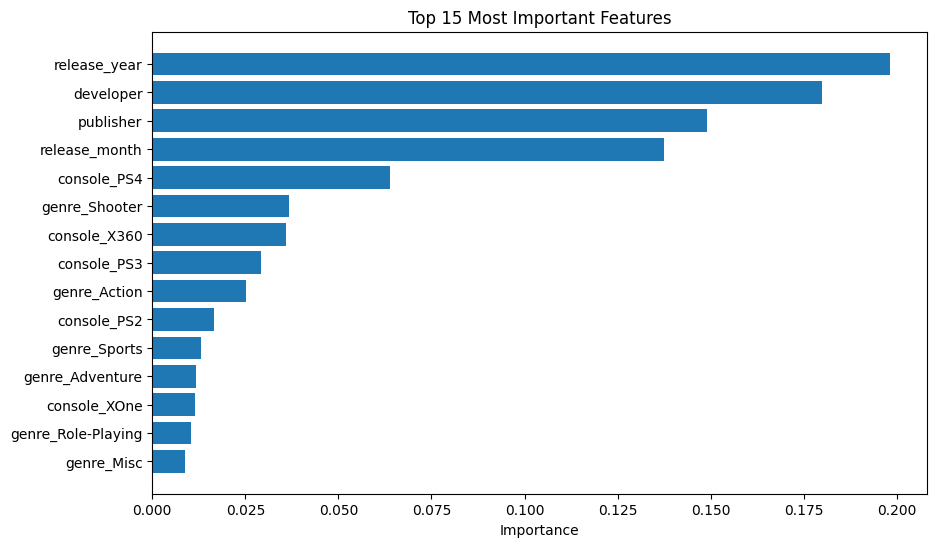

In [24]:
importance_df = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
}).sort_values("Importance",ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10,6))
plt.barh(
    importance_df["Feature"].head(15),
    importance_df["Importance"].head(15)
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Most Important Features")
plt.show()

# 13. Conclusions / Conclusiones

## Results

| Model | Summary |
|------|---------|
| Linear Regression | Baseline model with limited predictive capability. |
| Linear Regression + Log | Reduced MAE but did not improve overall performance. |
| Random Forest | Best overall model, achieving the highest R² and the lowest prediction errors. |

## Main Findings

- `release_year` was the most influential feature.
- `developer` and `publisher` contributed significantly to prediction performance.
- Random Forest captured nonlinear relationships better than Linear Regression.

